<a href="https://colab.research.google.com/github/wiuver/tipis/blob/main/itz5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Лабораторная работа 5. Построение нечёткого аппроксиматора

##1. Следуя инструкциям в прикреплённых методических рекомендациях выполнить построение тестового нечёткого аппроксиматора типа Sugeno.

In [ ]:
!pip install simpful

  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful



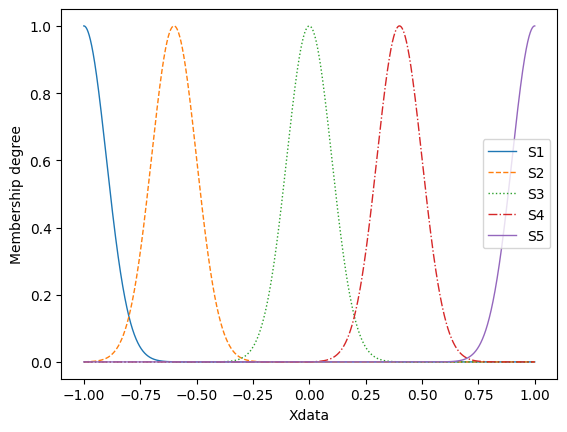

 * Detected Sugeno model type
test:  {'Y': np.float64(0.1599463567688349)}


In [ ]:
from simpful import *
import numpy as np

FS = FuzzySystem()

sigma = 0.1

S_1 = FuzzySet(function=Gaussian_MF(-1, sigma), term="S1")

S_2 = FuzzySet(function=Gaussian_MF(-0.6, sigma), term="S2")

S_3 = FuzzySet(function=Gaussian_MF(0, sigma), term="S3")

S_4 = FuzzySet(function=Gaussian_MF(0.4, sigma), term="S4")

S_5 = FuzzySet(function=Gaussian_MF(1, sigma), term="S5")

FS.add_linguistic_variable("X", LinguisticVariable([S_1, S_2, S_3, S_4, S_5], concept="Xdata", universe_of_discourse=[-1,1]))

FS.plot_variable('X')

#константа
FS.set_crisp_output_value("Y1", 1)
FS.set_crisp_output_value("Y2", 0.36)
FS.set_crisp_output_value("Y3", 0)
FS.set_crisp_output_value("Y4", 0.16)


#Правила
R1 = "IF (X IS S1) THEN (Y IS Y1)"
R2 = "IF (X IS S2) THEN (Y IS Y2)"
R3 = "IF (X IS S3) THEN (Y IS Y3)"
R4 = "IF (X IS S4) THEN (Y IS Y4)"
R5 = "IF (X IS S5) THEN (Y IS Y1)"
FS.add_rules([R1, R2, R3, R4, R5])


FS.set_variable("X", 0.4)
print ('test: ' ,FS.Sugeno_inference(['Y']))

##2. По аналогии построить нечёткий аппроксиматор типа Sugeno, отображающий зависимость между переменными x и у, согласно варианту.
##3. Определите тип полученной кривой. Проинтерпретировать полученные результаты. Привести в качестве примера 3-5 запросов (ввод входной величины x) и ответов на них (вывод величины y

  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful



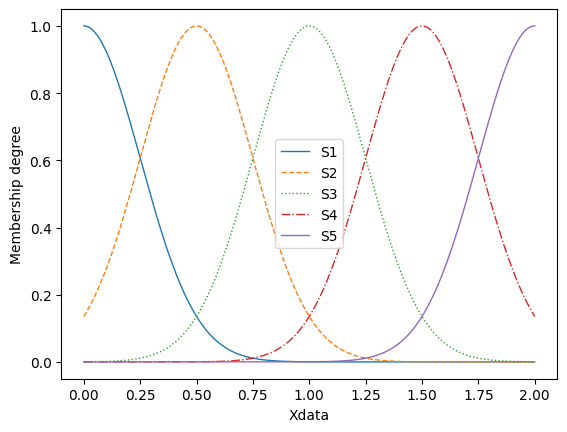

 * Detected Sugeno model type
test:  {'Y': np.float64(1.089673570437141)}
test:  {'Y': np.float64(1.3743289306395765)}
test:  {'Y': np.float64(1.3421926499619241)}
test:  {'Y': np.float64(0.36134582485267897)}


/tmp/ipython-input-3886864279.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


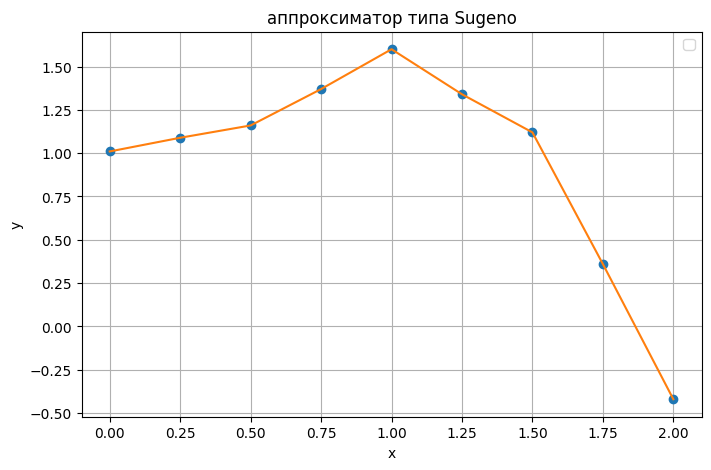

In [ ]:
from simpful import *
import numpy as np
import matplotlib.pyplot as plt


FS = FuzzySystem()

sigma = 0.25

S_1 = FuzzySet(function=Gaussian_MF(0, sigma), term="S1")

S_2 = FuzzySet(function=Gaussian_MF(0.5, sigma), term="S2")

S_3 = FuzzySet(function=Gaussian_MF(1, sigma), term="S3")

S_4 = FuzzySet(function=Gaussian_MF(1.5, sigma), term="S4")

S_5 = FuzzySet(function=Gaussian_MF(2, sigma), term="S5")

FS.add_linguistic_variable("X", LinguisticVariable([S_1, S_2, S_3, S_4, S_5], concept="Xdata", universe_of_discourse=[0,2]))

FS.plot_variable('X')

#константа
FS.set_crisp_output_value("Y1", 1.01)
FS.set_crisp_output_value("Y2", 1.16)
FS.set_crisp_output_value("Y3", 1.6)
FS.set_crisp_output_value("Y4", 1.12)
FS.set_crisp_output_value("Y5", -0.42)


#Правила
R1 = "IF (X IS S1) THEN (Y IS Y1)"
R2 = "IF (X IS S2) THEN (Y IS Y2)"
R3 = "IF (X IS S3) THEN (Y IS Y3)"
R4 = "IF (X IS S4) THEN (Y IS Y4)"
R5 = "IF (X IS S5) THEN (Y IS Y5)"
FS.add_rules([R1, R2, R3, R4, R5])


FS.set_variable("X", 0.25)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 0.75)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 1.25)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 1.75)
print ('test: ' ,FS.Sugeno_inference(['Y']))

X_points = np.array([0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
Y_values = [1.01, 1.089, 1.16, 1.37, 1.6, 1.34, 1.12, 0.36, -0.42]
#Визуализация
plt.figure(figsize=(8, 5))
plt.plot(X_points, Y_values, 'o')
plt.plot(X_points, Y_values, '-')
plt.xlabel("x")
plt.ylabel("y")
plt.title("аппроксиматор типа Sugeno")
plt.legend()
plt.grid(True)
plt.show()

##4. Проведите исследование влияния настроек нечёткой системы на результат работы:
Изменяя следующие параметры поэтапно оценивайте изменение качества аппроксимации (среднеквадратичное отклонение выхода модели от выхода исходной табличной функции в известных узлах (trainData) обучающей выборки и в узлах тестовой выборки (testData), которая не использовалась для настройки нечёткого аппроксиматора):

- тип функции принадлежности (тип кривой - gaussmf, trimf и пр.) - используйте поочерёдно 3-5 типов кривых для задания функций принадлежности входного параметра. Выберите наилучший вариант и остановитесь на нём (меняется в окне каждой переменной). Для этого варианта обеспечьте наилучшую гладкость функции (и/или наименьшее отклонение от точек testData) за счёт варьирования параметров (например, ширины) функции принадлежности всех нечётких множеств.

  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful



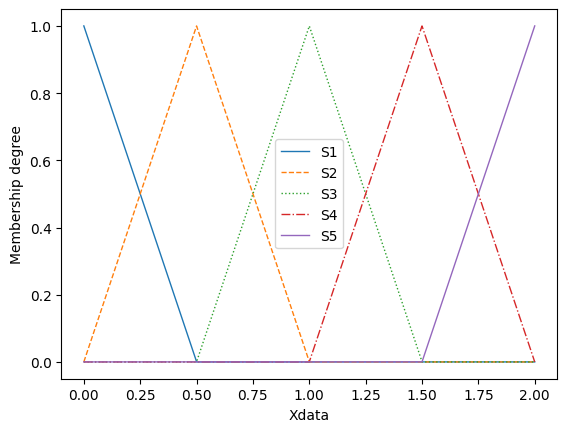

 * Detected Sugeno model type
test:  {'Y': 1.085}
test:  {'Y': 1.38}
test:  {'Y': 1.36}
test:  {'Y': 0.3500000000000001}


/tmp/ipython-input-2760804446.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


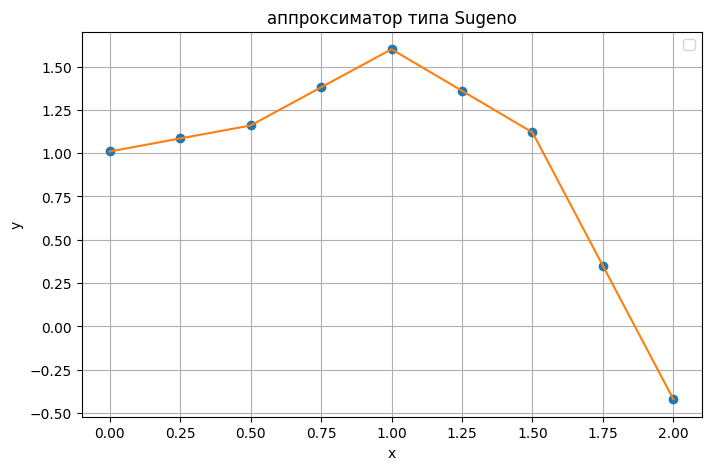

  ____  __  _  _  ____  ____  _  _  __   
 / ___)(  )( \/ )(  _ \(  __)/ )( \(  ) v2.12.0 
 \___ \ )( / \/ \ ) __/ ) _) ) \/ (/ (_/\ 
 (____/(__)\_)(_/(__)  (__)  \____/\____/

 https://github.com/aresio/simpful



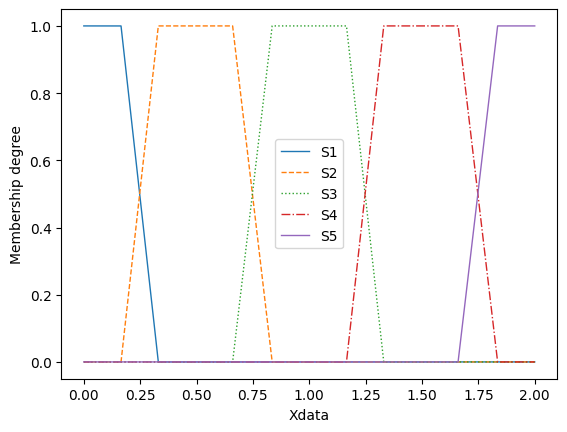

 * Detected Sugeno model type
test:  {'Y': 1.0872727272727274}
test:  {'Y': 1.3862857142857143}
test:  {'Y': 1.352727272727273}
test:  {'Y': 0.3279999999999996}


/tmp/ipython-input-2760804446.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


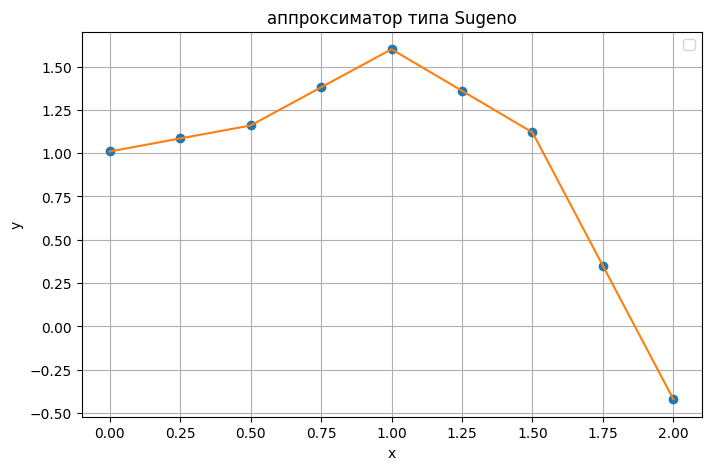

In [ ]:
from simpful import *
import numpy as np
import matplotlib.pyplot as plt

# Triangle

FS = FuzzySystem()

S_1 = FuzzySet(function=Triangular_MF(0, 0, 0.5), term="S1")

S_2 = FuzzySet(function=Triangular_MF(0, 0.5, 1), term="S2")

S_3 = FuzzySet(function=Triangular_MF(0.5, 1, 1.5), term="S3")

S_4 = FuzzySet(function=Triangular_MF(1, 1.5, 2), term="S4")

S_5 = FuzzySet(function=Triangular_MF(1.5, 2, 2), term="S5")

FS.add_linguistic_variable("X", LinguisticVariable([S_1, S_2, S_3, S_4, S_5], concept="Xdata", universe_of_discourse=[0,2]))

FS.plot_variable('X')

#константа
FS.set_crisp_output_value("Y1", 1.01)
FS.set_crisp_output_value("Y2", 1.16)
FS.set_crisp_output_value("Y3", 1.6)
FS.set_crisp_output_value("Y4", 1.12)
FS.set_crisp_output_value("Y5", -0.42)


#Правила
R1 = "IF (X IS S1) THEN (Y IS Y1)"
R2 = "IF (X IS S2) THEN (Y IS Y2)"
R3 = "IF (X IS S3) THEN (Y IS Y3)"
R4 = "IF (X IS S4) THEN (Y IS Y4)"
R5 = "IF (X IS S5) THEN (Y IS Y5)"
FS.add_rules([R1, R2, R3, R4, R5])


FS.set_variable("X", 0.25)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 0.75)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 1.25)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 1.75)
print ('test: ' ,FS.Sugeno_inference(['Y']))

X_points = np.array([0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
Y_values = [1.01, 1.085, 1.16, 1.38, 1.6, 1.36, 1.12, 0.35, -0.42]
# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(X_points, Y_values, 'o')
plt.plot(X_points, Y_values, '-')
plt.xlabel("x")
plt.ylabel("y")
plt.title("аппроксиматор типа Sugeno")
plt.legend()
plt.grid(True)
plt.show()


# Trapezoid

FS = FuzzySystem()

S_1 = FuzzySet(function=Trapezoidal_MF(0, 0, 0.165, 0.33), term="S1")

S_2 = FuzzySet(function=Trapezoidal_MF(0.165, 0.33, 0.66, 0.835), term="S2")

S_3 = FuzzySet(function=Trapezoidal_MF(0.66, 0.835, 1.165, 1.33), term="S3")

S_4 = FuzzySet(function=Trapezoidal_MF(1.165, 1.33, 1.66, 1.835), term="S4")

S_5 = FuzzySet(function=Trapezoidal_MF(1.66, 1.835, 2, 2), term="S5")

FS.add_linguistic_variable("X", LinguisticVariable([S_1, S_2, S_3, S_4, S_5], concept="Xdata", universe_of_discourse=[0,2]))

FS.plot_variable('X')

#константа
FS.set_crisp_output_value("Y1", 1.01)
FS.set_crisp_output_value("Y2", 1.16)
FS.set_crisp_output_value("Y3", 1.6)
FS.set_crisp_output_value("Y4", 1.12)
FS.set_crisp_output_value("Y5", -0.42)


#Правила
R1 = "IF (X IS S1) THEN (Y IS Y1)"
R2 = "IF (X IS S2) THEN (Y IS Y2)"
R3 = "IF (X IS S3) THEN (Y IS Y3)"
R4 = "IF (X IS S4) THEN (Y IS Y4)"
R5 = "IF (X IS S5) THEN (Y IS Y5)"
FS.add_rules([R1, R2, R3, R4, R5])


FS.set_variable("X", 0.25)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 0.75)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 1.25)
print ('test: ' ,FS.Sugeno_inference(['Y']))

FS.set_variable("X", 1.75)
print ('test: ' ,FS.Sugeno_inference(['Y']))

X_points = np.array([0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
Y_values = [1.01, 1.085, 1.16, 1.38, 1.6, 1.36, 1.12, 0.35, -0.42]
# Визуализация
plt.figure(figsize=(8, 5))
plt.plot(X_points, Y_values, 'o')
plt.plot(X_points, Y_values, '-')
plt.xlabel("x")
plt.ylabel("y")
plt.title("аппроксиматор типа Sugeno")
plt.legend()
plt.grid(True)
plt.show()